Import Data and Packages

In [1]:
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
df=pd.read_csv('diabetes.csv')

Gain some general basic info about the data

In [2]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

EDA

array([[<AxesSubplot: title={'center': 'Pregnancies'}>,
        <AxesSubplot: title={'center': 'Glucose'}>,
        <AxesSubplot: title={'center': 'BloodPressure'}>],
       [<AxesSubplot: title={'center': 'SkinThickness'}>,
        <AxesSubplot: title={'center': 'Insulin'}>,
        <AxesSubplot: title={'center': 'BMI'}>],
       [<AxesSubplot: title={'center': 'DiabetesPedigreeFunction'}>,
        <AxesSubplot: title={'center': 'Age'}>,
        <AxesSubplot: title={'center': 'Outcome'}>]], dtype=object)

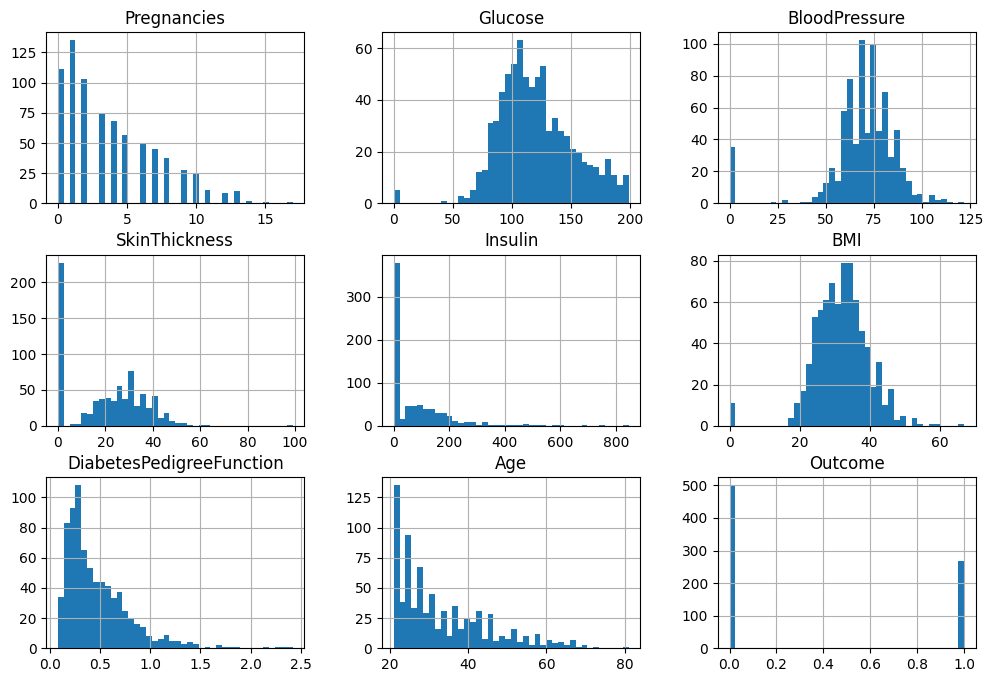

In [6]:
df.hist(bins=40,figsize=(12,8))    

Outliers

In [7]:
#Outlier Equation
def outlier_threshhold(dataframe,column,q1=0.25,q3=0.75):
    Q1=dataframe[column].quantile(q1)
    Q3=dataframe[column].quantile(q3)
    iqr=Q3-Q1
    up_limit=Q3+1.5*iqr
    low_limit=Q1-1.5*iqr
    return low_limit,up_limit
#Checking Outliers 
def check_outliers(dataframe,column):
    low_limit,up_limit=outlier_threshhold(dataframe,column)
    outliers=(dataframe[column]>up_limit) | (dataframe[column]<low_limit)
    if outliers.any():
        return True
    else:
        return False

#Removing the Outliers
def replace_with_threshholds(dataframe,column):
    low_limit,up_limit=outlier_threshhold(dataframe,column)
    dataframe.loc[(dataframe[column]<low_limit),column]=low_limit
    dataframe.loc[(dataframe[column]>up_limit),column]=up_limit    

Plotting Outliers

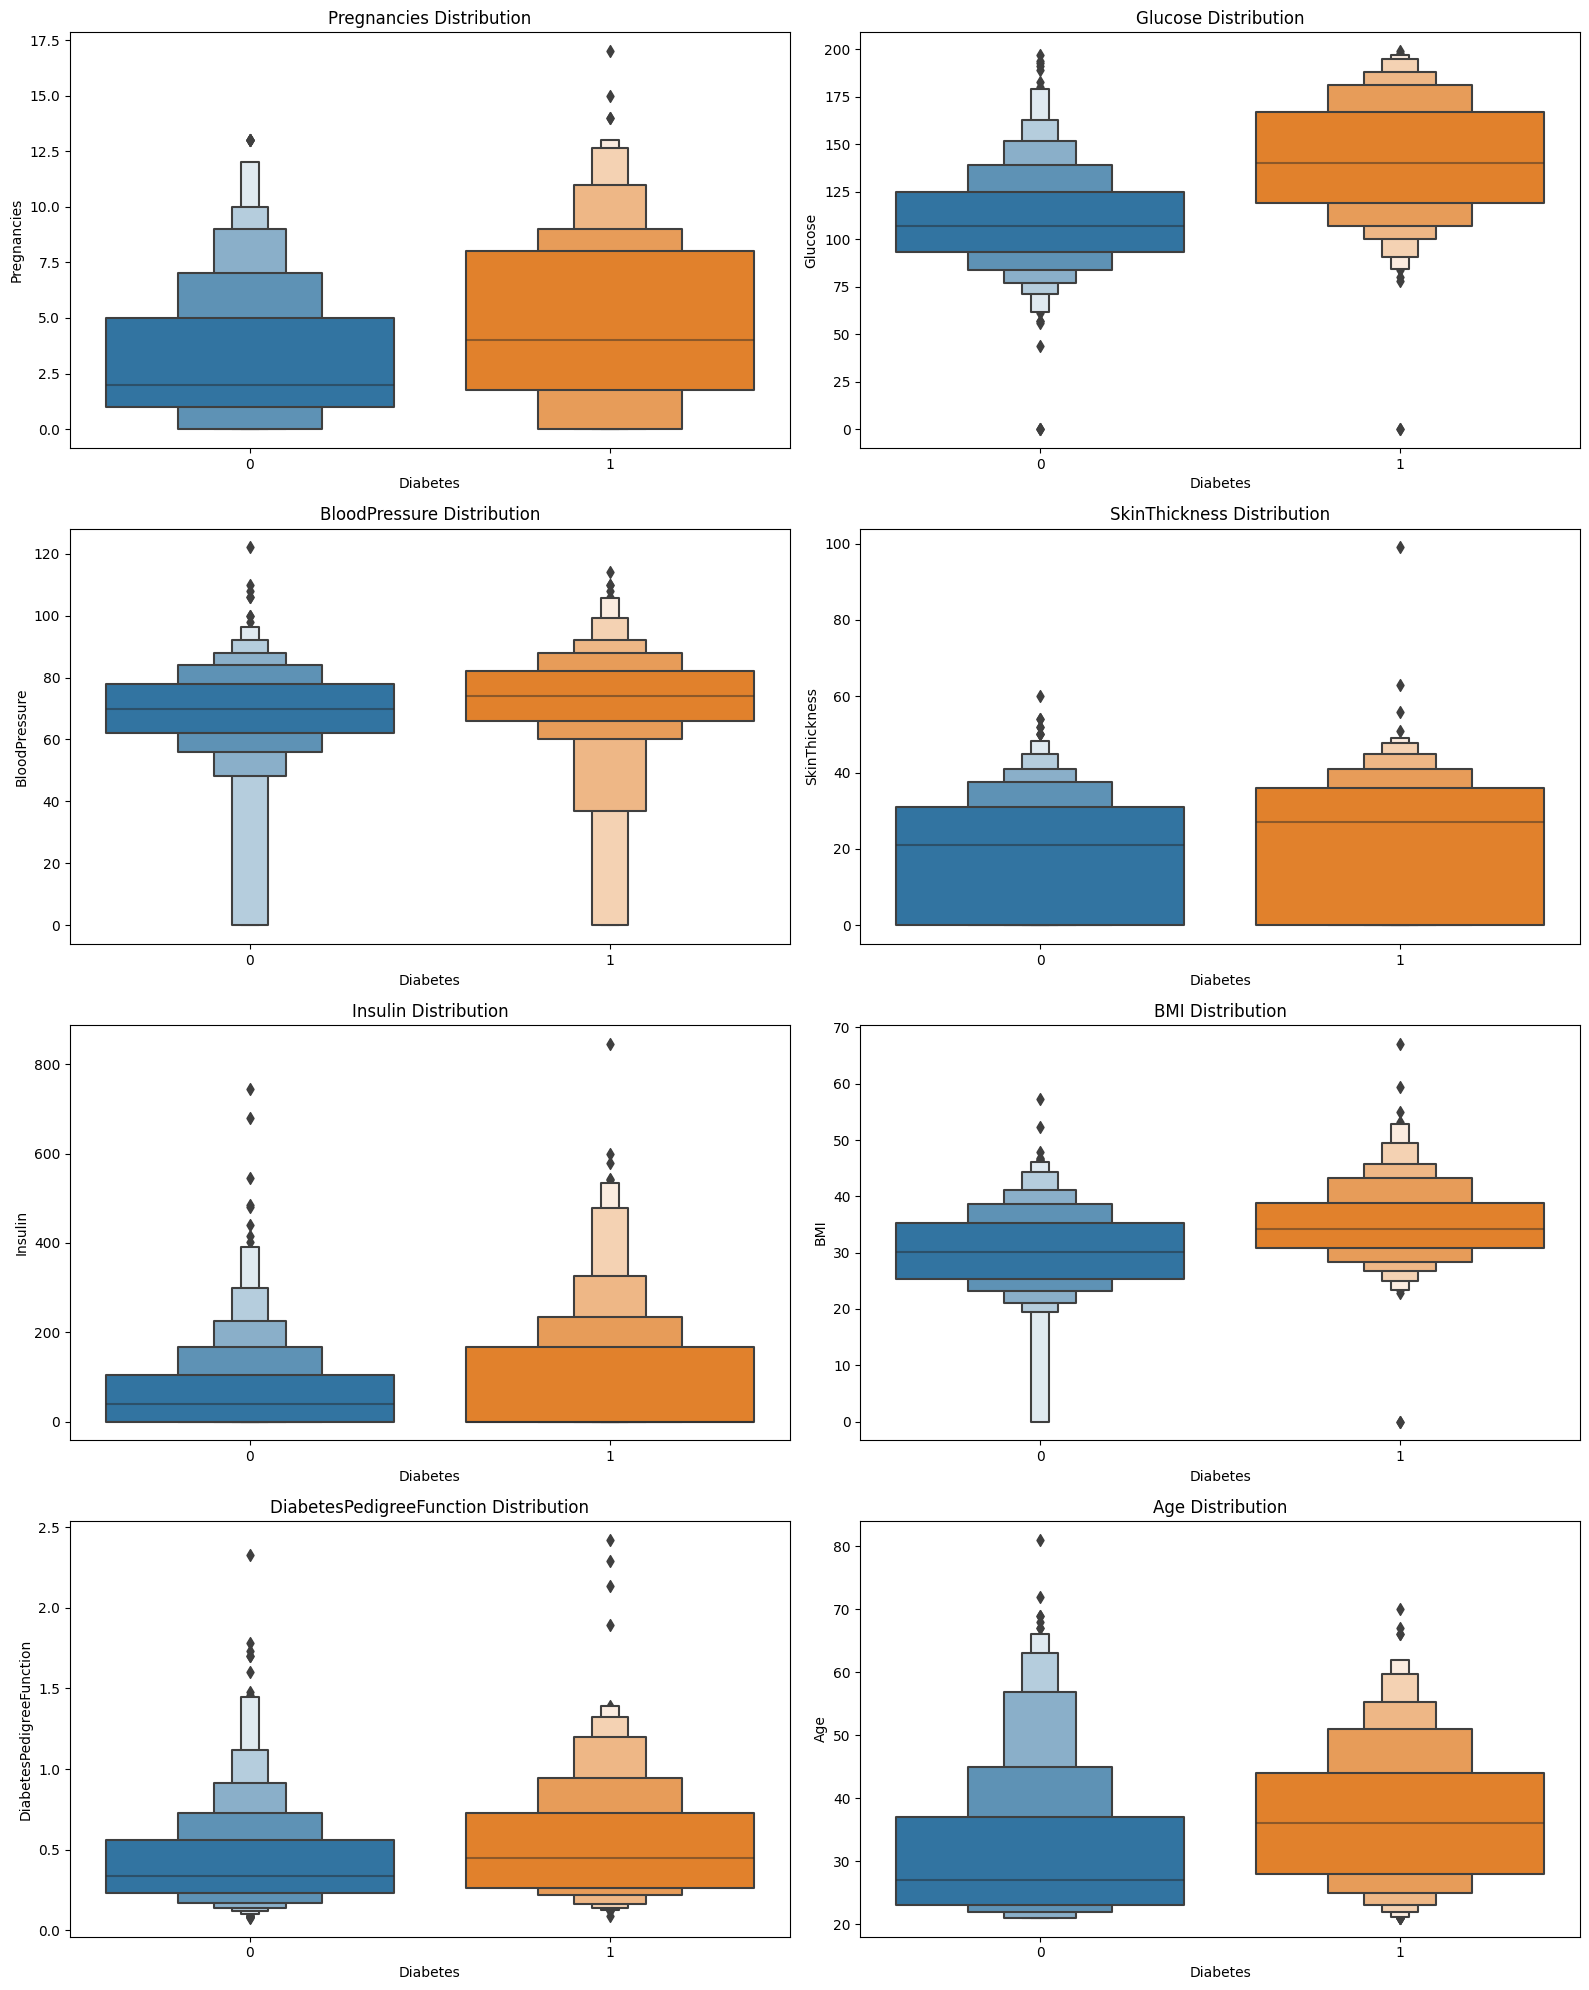

In [8]:
fig,axes=plt.subplots(nrows=len(df.columns)//2 ,ncols=2,figsize=(16,20))#Subplot let's us 
for idx,column in enumerate(df.drop(columns='Outcome')):
    row_idx=idx//2
    col_idx=idx%2
    sns.boxenplot(x='Outcome',y=column,data=df,ax=axes[row_idx,col_idx])
    axes[row_idx,col_idx].set_xlabel('Diabetes')
    axes[row_idx,col_idx].set_ylabel(column)
    axes[row_idx, col_idx].set_title(f"{column} Distribution")
plt.tight_layout()
plt.show()    

Remove Outliers

In [9]:
for column in (df.drop(columns='Outcome').columns):
    replace_with_threshholds(df,column)
    print(column,check_outliers(df,column))

Pregnancies False
Glucose False
BloodPressure False
SkinThickness False
Insulin False
BMI False
DiabetesPedigreeFunction False
Age False


In [10]:
df.shape

(768, 9)

Colinearity

<AxesSubplot: >

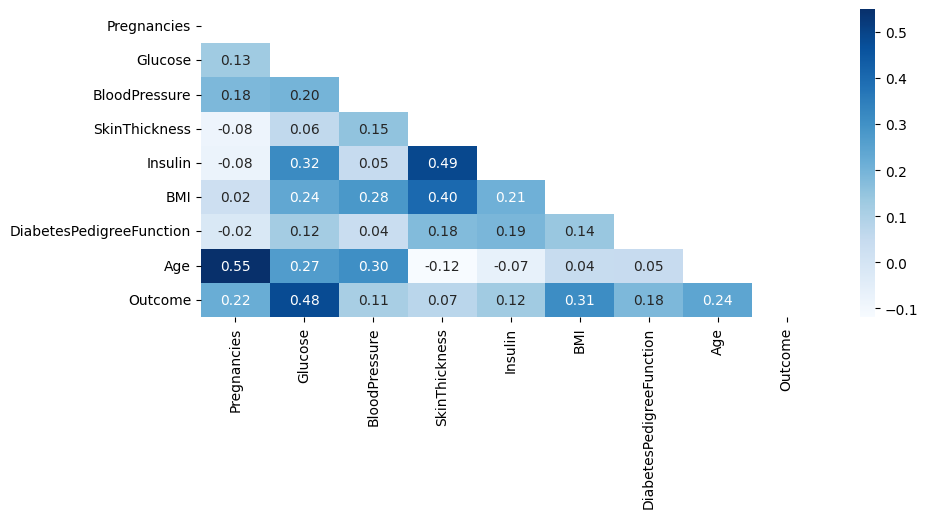

In [11]:
#We Try to find a linear correlations between the outcome and the other features
corr=df.corr()
mask=np.triu(corr)
plt.figure(figsize=(10,4))
sns.heatmap(corr,annot=True,mask=mask,cmap='Blues',fmt='.2f')


In [12]:
#We find out features like Pregnancy,Age and Glucose have high correlation to the outcome
#That does not mean the rest of the columns are worthless;We try to find out if there are other realtionships that could be nonlinear 

Train Test Split

In [13]:
#Before Doing any drastic change we should split the data to seprate train test sets
labels=df.drop(columns="Outcome")
target=df['Outcome']
X_train,X_test,y_train,y_test=train_test_split(labels,target,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(614, 8) (154, 8) (614,) (154,)


Logistic Regrision

In [14]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred=log_reg.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(y_pred.shape)
print(accuracy)

(154,)
0.7727272727272727


Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier
rd_class=RandomForestClassifier()
rd_class.fit(X_train,y_train)
y_pred=rd_class.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.7532467532467533


SVC

In [16]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.7662337662337663


Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt_class=DecisionTreeClassifier()
dt_class.fit(X_train,y_train)
y_pred=dt_class.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.7467532467532467


SGD Classfier

In [18]:
from sklearn.linear_model import SGDClassifier
sgd=SGDClassifier()
sgd.fit(X_train,y_train)
y_pred=sgd.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.6038961038961039


Try to play with hyper parameters

In [19]:
#change the train test ratio
X_train,X_test,y_train,y_test=train_test_split(labels,target,test_size=0.3,random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(537, 8) (231, 8) (537,) (231,)


In [20]:
models=[LogisticRegression(),RandomForestClassifier(),SVC(),DecisionTreeClassifier(),SGDClassifier()]
for i in models:
    i.fit(X_train,y_train)
    y_pred=i.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(i," ",accuracy)

LogisticRegression()   0.7445887445887446
RandomForestClassifier()   0.7272727272727273
SVC()   0.7489177489177489
DecisionTreeClassifier()   0.7186147186147186
SGDClassifier()   0.670995670995671


In [21]:
#We Notice that the accuracy of logistic regresion decreased 3%,Random Forest increased by 0.3%,SVC decreased 2%,Descision Tree decreased 2%,Sgd increased by 2%

In [22]:
#Decrease the test size to 0.1
X_train,X_test,y_train,y_test=train_test_split(labels,target,test_size=0.1,random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(691, 8) (77, 8) (691,) (77,)


In [23]:
models=[LogisticRegression(),RandomForestClassifier(),SVC(),DecisionTreeClassifier(),SGDClassifier()]
for i in models:
    i.fit(X_train,y_train)
    y_pred=i.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(i," ",accuracy)

LogisticRegression()   0.7272727272727273
RandomForestClassifier()   0.7012987012987013
SVC()   0.7662337662337663
DecisionTreeClassifier()   0.7662337662337663
SGDClassifier()   0.7012987012987013


In [24]:
#Only Decision tree and random forest increased 2%  the rest got drasticly declined 

In [25]:
#There is some other hyprematers to play with like(Pooling size,Batch size,Learning rate in optimization algorithms,The choice of cost or loss function the model will use)
#But someother time cause I am exhausted